<a href="https://colab.research.google.com/github/talhanoor23/Deep-Learning-Experiments/blob/main/Classification/load_Pretrained_classificationModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import joblib

In [ ]:
load_model = joblib.load('/content/fashion_mnist_model_5.joblib')

# **Import_Datasets**

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
(train_x, train_y), (test_x, test_y) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
train_x.shape, train_y.shape, test_x.shape, test_y.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

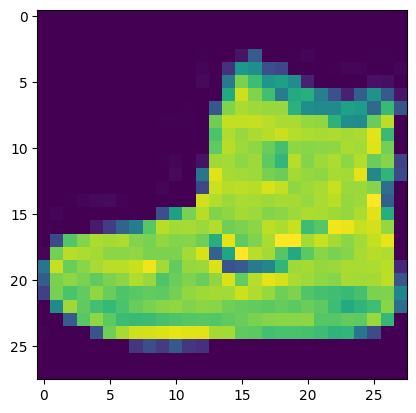

In [ ]:
plt.imshow(train_x[0])

In [ ]:
label_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

Text(0.5, 1.0, 'Ankle boot')

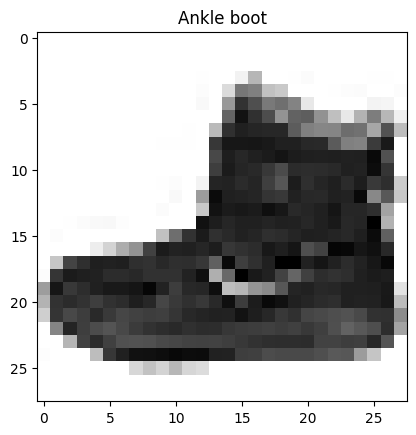

In [ ]:
plt.imshow(train_x[0],cmap=plt.cm.binary )#cmap='gray', cmap k through ap different views lay sakty hain picture ky.
plt.title(label_names[train_y[0]])

# Preprocess_Data

In [ ]:
train_x_norm = train_x/255.0
test_x_norm = test_x/255.0

# **Make_Predictions**

In [ ]:
unique_labels = np.unique(train_y)
class_images = {}
for label in unique_labels:
  class_index = np.where(train_y == label)[0][0]
  class_images[label] = train_x_norm[class_index]

In [ ]:
import random
def plot_random_image(model, image, true_label, class_names, class_images):
  random_index = random.randint(0, len(image))
  target_image, target_label = image[random_index], true_label[random_index]
  pred_probs = model.predict(target_image.reshape(1, 28, 28))
  preds = pred_probs.argmax(axis=1)
  pred_label = class_names[preds[0]]
  pred_image = class_images[preds[0]]

  plt.figure(figsize=(15, 7))
  plt.subplot(1, 2, 1)
  plt.imshow(target_image, cmap=plt.cm.binary)
  plt.title(f'Actual:{class_names[target_label]}', fontsize=15) # target_label is already an integer index

  if pred_label == class_names[target_label]:  # Compare pred_label with the string from class_names
    plt.subplot(1, 2, 2)
    plt.imshow(pred_image, cmap=plt.cm.binary)
    plt.title(f'Predicted:{pred_label}, True',c='green', fontsize=15)
  else:
    plt.subplot(1, 2, 2)
    plt.imshow(pred_image, cmap=plt.cm.binary)
    plt.title(f'Predicted:{pred_label}, False',c='red', fontsize=15)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


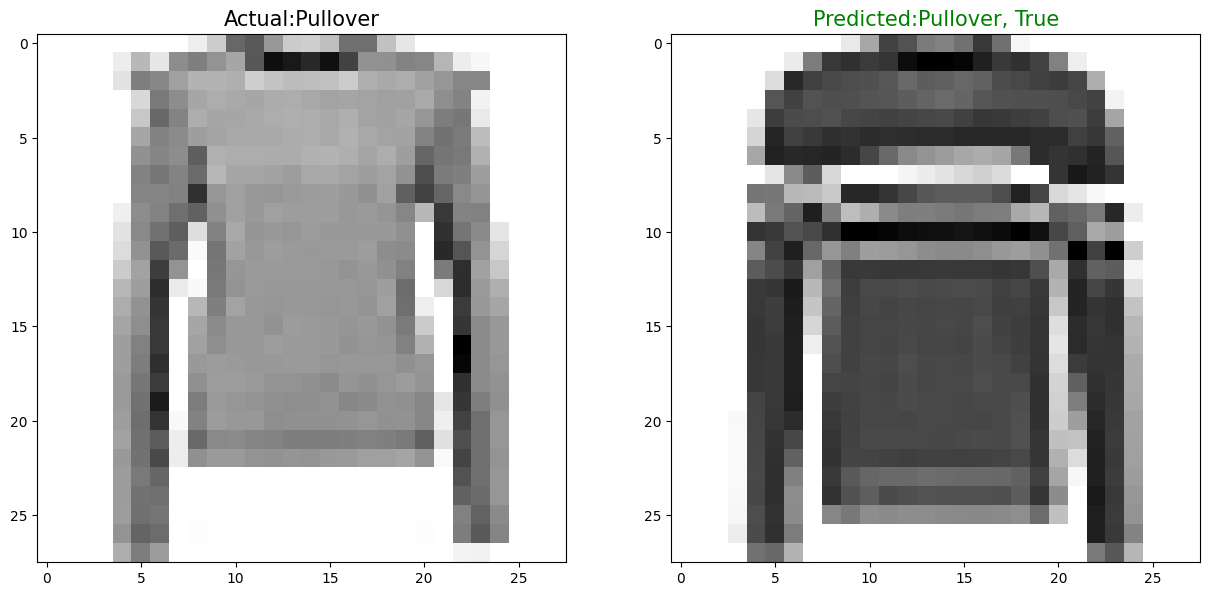

In [ ]:
plot_random_image(load_model,test_x_norm,test_y,label_names, class_images)